# **Project Summary Final**

Notebook ini hanya membaca input dari daftar file yang ditetapkan dan hanya menghasilkan output final pada folder `results/project_summary`. Output dibatasi menggunakan whitelist agar tidak ada file tambahan yang dibuat di luar daftar ringkasan akhir.

In [1]:
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

warnings.filterwarnings("ignore")


# Project path

CURRENT_DIR = Path.cwd()
PROJECT_ROOT = CURRENT_DIR.parent if CURRENT_DIR.name.lower() == "notebooks" else CURRENT_DIR

OUTPUT_DIR = PROJECT_ROOT / "results" / "project_summary"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


# Input files

INPUT_FILE_PATHS = {
    "gold_macro": PROJECT_ROOT / "data" / "processed" / "gold_macro_processed_5d.csv",
    "base": PROJECT_ROOT / "data" / "processed" / "base_dataset_5d.csv",

    "arimax_benchmark": PROJECT_ROOT / "results" / "arimax_5d" / "arimax_benchmarks_5d.csv",
    "arimax_summary": PROJECT_ROOT / "results" / "arimax_5d" / "arimax_summary_5d.json",
    "arimax_test_pred": PROJECT_ROOT / "results" / "arimax_5d" / "arimax_test_predictions_5d.csv",
    "arimax_ablation": PROJECT_ROOT / "results" / "arimax_5d" / "stage_b_ablation_arimax_5d.csv",

    "xgboost_summary": PROJECT_ROOT / "results" / "xgboost_5d" / "xgboost_summary_5d.json",
    "xgboost_test_pred": PROJECT_ROOT / "results" / "xgboost_5d" / "xgboost_test_predictions_5d.csv",
    "xgboost_ablation": PROJECT_ROOT / "results" / "xgboost_5d" / "stage_b_ablation_xgboost_5d.csv",

    "lstm_summary": PROJECT_ROOT / "results" / "lstm_5d" / "lstm_summary_5d.json",
    "lstm_test_pred": PROJECT_ROOT / "results" / "lstm_5d" / "lstm_test_predictions_5d.csv",
    "lstm_ablation": PROJECT_ROOT / "results" / "lstm_5d" / "stage_b_ablation_lstm_5d.csv",
}

REPORT_PACKAGE_ORDER = ["FULL", "NO_G1", "NO_G2", "NO_G3", "GOLD_ONLY"]
MODEL_ORDER = ["ARIMAX", "XGBoost", "LSTM"]
METRIC_COLS = ["MAE", "RMSE", "DA"]

print("PROJECT_ROOT:", PROJECT_ROOT)
print("OUTPUT_DIR  :", OUTPUT_DIR)
print("Input files :", len(INPUT_FILE_PATHS))


PROJECT_ROOT: c:\Users\Afzi\Documents\BINUS\0. SKRIPSI\gold_forecasting_skripsi
OUTPUT_DIR  : c:\Users\Afzi\Documents\BINUS\0. SKRIPSI\gold_forecasting_skripsi\results\project_summary
Input files : 12


### **Helper Functions**

In [2]:
def resolve_input_file(key: str) -> Path:
    """
    Mengambil path file input hanya dari INPUT_FILE_PATHS.
    Fungsi ini sengaja tidak melakukan pencarian otomatis agar notebook
    tidak membaca file lain di luar daftar input yang sudah ditetapkan.
    """
    if key not in INPUT_FILE_PATHS:
        raise KeyError(f"Input key tidak terdaftar: {key}")

    path = INPUT_FILE_PATHS[key]

    # Path relatif tetap didukung, tetapi konfigurasi utama memakai PROJECT_ROOT.
    if not path.is_absolute():
        path = PROJECT_ROOT / path

    if not path.exists():
        raise FileNotFoundError(
            f"File input tidak ditemukan untuk key '{key}': {path}\n"
            "Periksa kembali INPUT_FILE_PATHS pada cell konfigurasi."
        )

    return path


def clean_output_directory() -> None:
    """
    Menghapus output lama agar folder results/project_summary hanya berisi
    file final yang dibuat ulang oleh notebook ini.
    """
    for pattern in ["*.csv", "*.png", "*.json"]:
        for path in OUTPUT_DIR.glob(pattern):
            path.unlink()


def load_csv(path: Path, date_cols=None) -> pd.DataFrame:
    df = pd.read_csv(path)
    if date_cols:
        for col in date_cols:
            if col in df.columns:
                df[col] = pd.to_datetime(df[col])
    return df


def load_json(path: Path) -> dict:
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


def save_table(df: pd.DataFrame, filename: str, index: bool = False) -> Path:
    path = OUTPUT_DIR / filename
    df.to_csv(path, index=index)
    return path


def save_fig(filename: str) -> Path:
    path = OUTPUT_DIR / filename
    plt.tight_layout()
    plt.savefig(path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()
    return path


def compute_metrics(df: pd.DataFrame, actual_col="TARGET_5D", pred_col="PRED") -> dict:
    actual = df[actual_col].astype(float).to_numpy()
    pred = df[pred_col].astype(float).to_numpy()

    mae = np.mean(np.abs(actual - pred))
    rmse = np.sqrt(np.mean((actual - pred) ** 2))

    if "TARGET_DIRECTION" in df.columns and "PRED_DIRECTION" in df.columns:
        da = np.mean(
            df["TARGET_DIRECTION"].astype(int).to_numpy()
            == df["PRED_DIRECTION"].astype(int).to_numpy()
        )
    else:
        da = np.mean((actual > 0) == (pred > 0))

    return {
        "MAE": mae,
        "RMSE": rmse,
        "DA": da,
    }


def split_by_target_date(df: pd.DataFrame, target_date_col="TARGET_DATE") -> pd.Series:
    year = pd.to_datetime(df[target_date_col]).dt.year

    split = pd.Series(index=df.index, dtype="object")
    split[(year >= 2010) & (year <= 2022)] = "Train"
    split[year == 2023] = "Validation"
    split[(year >= 2024) & (year <= 2025)] = "Test"
    return split


def filter_report_packages(df: pd.DataFrame, package_col="package") -> pd.DataFrame:
    if package_col not in df.columns:
        return df.copy()

    out = df[df[package_col].astype(str).isin(REPORT_PACKAGE_ORDER)].copy()
    out[package_col] = pd.Categorical(out[package_col], categories=REPORT_PACKAGE_ORDER, ordered=True)
    out = out.sort_values(package_col).reset_index(drop=True)
    return out


def best_package_from_ablation(ablation_df: pd.DataFrame) -> str:
    clean_df = filter_report_packages(ablation_df)
    if clean_df.empty:
        return None
    return clean_df.sort_values(["MAE", "RMSE"], ascending=[True, True]).iloc[0]["package"]


def format_float_cols(df: pd.DataFrame, cols=None, decimals=6) -> pd.DataFrame:
    out = df.copy()
    cols = cols or out.select_dtypes(include=[np.number]).columns
    for col in cols:
        if col in out.columns:
            out[col] = out[col].astype(float).round(decimals)
    return out



# Statistical significance helpers (Diebold-Mariano & Wilcoxon)

# Target return 5 hari yang diprediksi setiap hari menghasilkan jendela
# prediksi yang tumpang tindih, sehingga error antar observasi
# berautokorelasi hingga lag (H-1) = 4 (pola MA(4)). Karena itu varians
# DM dihitung dengan estimator HAC/Newey-West (bobot Bartlett, lag = H-1)
# dan statistiknya dikoreksi memakai faktor Harvey-Leybourne-Newey (1997)
# lalu dibandingkan terhadap distribusi t (bukan normal).

FORECAST_HORIZON = 5  # h; lag Newey-West = h - 1 = 4


def _hac_long_run_var(d: np.ndarray, lags: int) -> float:
    """Varians jangka panjang d_t dengan bobot Bartlett (Newey-West)."""
    n = len(d)
    dev = d - d.mean()
    var = (dev @ dev) / n
    for k in range(1, lags + 1):
        weight = 1.0 - k / (lags + 1.0)
        var += 2.0 * weight * ((dev[k:] @ dev[:-k]) / n)
    return var


def diebold_mariano(errors_a, errors_b, horizon: int = FORECAST_HORIZON, loss: str = "abs") -> dict:
    """
    Uji Diebold-Mariano untuk dua himpunan error prediksi yang selaras.
        loss="abs"    -> selisih loss absolut (sejalan dengan MAE)
        loss="square" -> selisih loss kuadrat (sejalan dengan RMSE)
    Varians memakai HAC/Newey-West (lag = horizon - 1) lalu statistik
    dikoreksi dengan faktor Harvey-Leybourne-Newey dan dibandingkan ke
    distribusi t dengan derajat bebas n - 1.
    """
    ea = np.asarray(errors_a, dtype=float)
    eb = np.asarray(errors_b, dtype=float)
    if loss == "abs":
        d = np.abs(ea) - np.abs(eb)
    elif loss == "square":
        d = ea ** 2 - eb ** 2
    else:
        raise ValueError("loss harus 'abs' atau 'square'")

    n = len(d)
    lags = horizon - 1
    mean_diff = d.mean()
    var_mean = _hac_long_run_var(d, lags) / n
    dm_raw = mean_diff / np.sqrt(var_mean)

    hln_factor = np.sqrt((n + 1 - 2 * horizon + horizon * (horizon - 1) / n) / n)
    dm_stat = dm_raw * hln_factor
    p_value = 2 * stats.t.cdf(-abs(dm_stat), df=n - 1)

    return {
        "mean_loss_diff": mean_diff,
        "dm_stat": dm_stat,
        "p_value": p_value,
        "n": n,
        "lags": lags,
    }


def wilcoxon_loss_diff(errors_a, errors_b, loss: str = "abs") -> float:
    """p-value Wilcoxon signed-rank pada selisih loss (pemeriksaan tahan-outlier)."""
    ea = np.asarray(errors_a, dtype=float)
    eb = np.asarray(errors_b, dtype=float)
    d = (np.abs(ea) - np.abs(eb)) if loss == "abs" else (ea ** 2 - eb ** 2)
    try:
        _, p = stats.wilcoxon(d, zero_method="wilcox", alternative="two-sided")
        return p
    except ValueError:
        return np.nan


### **Load Input Files**

In [3]:

# Validate, cleanup, and load input files

clean_output_directory()

paths = {key: resolve_input_file(key) for key in INPUT_FILE_PATHS.keys()}

path_summary = pd.DataFrame({
    "key": list(paths.keys()),
    "filename": [paths[k].name for k in paths.keys()],
    "path": [str(paths[k]) for k in paths.keys()]
})

display(path_summary)


# Load data

gold_macro = load_csv(paths["gold_macro"], date_cols=["DATE"])
base = load_csv(paths["base"], date_cols=["DATE", "TARGET_DATE"])

summaries = {
    "ARIMAX": load_json(paths["arimax_summary"]),
    "XGBoost": load_json(paths["xgboost_summary"]),
    "LSTM": load_json(paths["lstm_summary"]),
}

test_predictions = {
    "ARIMAX": load_csv(paths["arimax_test_pred"], date_cols=["DATE", "TARGET_DATE"]),
    "XGBoost": load_csv(paths["xgboost_test_pred"], date_cols=["DATE", "TARGET_DATE"]),
    "LSTM": load_csv(paths["lstm_test_pred"], date_cols=["DATE", "TARGET_DATE"]),
}

ablation_results = {
    "ARIMAX": load_csv(paths["arimax_ablation"]),
    "XGBoost": load_csv(paths["xgboost_ablation"]),
    "LSTM": load_csv(paths["lstm_ablation"]),
}

arimax_benchmark = load_csv(paths["arimax_benchmark"])

,key,filename,path
0,gold_macro,gold_macro_processed_5d.csv,c:\Users\Afzi\Documents\BINUS\0. SKRIPSI\gold_...
1,base,base_dataset_5d.csv,c:\Users\Afzi\Documents\BINUS\0. SKRIPSI\gold_...
2,arimax_benchmark,arimax_benchmarks_5d.csv,c:\Users\Afzi\Documents\BINUS\0. SKRIPSI\gold_...
3,arimax_summary,arimax_summary_5d.json,c:\Users\Afzi\Documents\BINUS\0. SKRIPSI\gold_...
4,arimax_test_pred,arimax_test_predictions_5d.csv,c:\Users\Afzi\Documents\BINUS\0. SKRIPSI\gold_...
5,arimax_ablation,stage_b_ablation_arimax_5d.csv,c:\Users\Afzi\Documents\BINUS\0. SKRIPSI\gold_...
6,xgboost_summary,xgboost_summary_5d.json,c:\Users\Afzi\Documents\BINUS\0. SKRIPSI\gold_...
7,xgboost_test_pred,xgboost_test_predictions_5d.csv,c:\Users\Afzi\Documents\BINUS\0. SKRIPSI\gold_...
8,xgboost_ablation,stage_b_ablation_xgboost_5d.csv,c:\Users\Afzi\Documents\BINUS\0. SKRIPSI\gold_...
9,lstm_summary,lstm_summary_5d.json,c:\Users\Afzi\Documents\BINUS\0. SKRIPSI\gold_...


### **Split Summary**

In [4]:
base["SPLIT"] = split_by_target_date(base)

split_summary = (
    base.groupby("SPLIT", dropna=False)
    .agg(
        Rows=("TARGET_5D", "size"),
        Start_DATE=("DATE", "min"),
        End_DATE=("DATE", "max"),
        Start_TARGET_DATE=("TARGET_DATE", "min"),
        End_TARGET_DATE=("TARGET_DATE", "max"),
        Positive_Target_Ratio=("TARGET_DIRECTION", "mean"),
    )
    .reset_index()
)

split_summary["Split_Order"] = split_summary["SPLIT"].map({"Train": 1, "Validation": 2, "Test": 3})
split_summary = split_summary.sort_values("Split_Order").drop(columns="Split_Order").reset_index(drop=True)

save_table(split_summary, "01_split_summary.csv")
display(format_float_cols(split_summary))

,SPLIT,Rows,Start_DATE,End_DATE,Start_TARGET_DATE,End_TARGET_DATE,Positive_Target_Ratio
0,Train,3263.0,2010-01-05,2022-12-22,2010-01-12,2022-12-30,0.538462
1,Validation,250.0,2022-12-23,2023-12-21,2023-01-03,2023-12-29,0.520000
2,Test,503.0,2023-12-22,2025-12-22,2024-01-02,2025-12-30,0.654076


### **Statistik Deskriptif**

In [5]:
feature_cols = ["GOLD_RET", "DXY_RET", "SP500_RET", "OIL_RET", "US10Y_CHANGE", "VIX_LEVEL"]
target_cols = ["TARGET_5D"]

feature_stats = base[feature_cols].describe().T.reset_index().rename(columns={"index": "Variable"})
target_stats = base[target_cols].describe().T.reset_index().rename(columns={"index": "Variable"})

save_table(feature_stats, "02_feature_descriptive_stats.csv")
save_table(target_stats, "03_target_descriptive_stats.csv")

display(format_float_cols(feature_stats))
display(format_float_cols(target_stats))

,Variable,count,mean,std,min,25%,50%,75%,max
0,GOLD_RET,4016.0,0.000396,0.010233,-0.093538,-0.004498,0.000450,0.005901,0.059477
1,DXY_RET,4016.0,0.000069,0.004475,-0.023702,-0.002523,0.000096,0.002612,0.020528
2,SP500_RET,4016.0,0.000509,0.010925,-0.119841,-0.003802,0.000703,0.005699,0.095154
3,OIL_RET,4016.0,-0.000688,0.058182,-3.059661,-0.011715,0.000848,0.012296,0.376623
4,US10Y_CHANGE,4016.0,0.000082,0.053826,-0.322000,-0.032000,-0.000500,0.033000,0.269000
5,VIX_LEVEL,4016.0,18.421691,6.876931,9.140000,13.770000,16.685000,21.112501,82.690002


,Variable,count,mean,std,min,25%,50%,75%,max
0,TARGET_5D,4016.0,0.001947,0.022253,-0.134478,-0.011016,0.002683,0.015375,0.115988


### **Korelasi Fitur dengan Target**

In [6]:
corr_cols = feature_cols + ["TARGET_5D"]
corr_matrix = base[corr_cols].corr()

corr_with_target = (
    corr_matrix["TARGET_5D"]
    .drop("TARGET_5D")
    .sort_values(key=lambda s: s.abs(), ascending=False)
    .reset_index()
    .rename(columns={"index": "Feature", "TARGET_5D": "Correlation_With_TARGET_5D"})
)

display(format_float_cols(corr_with_target))

,Feature,Correlation_With_TARGET_5D
0,VIX_LEVEL,0.066489
1,US10Y_CHANGE,-0.024470
2,GOLD_RET,-0.021515
3,SP500_RET,0.011350
4,OIL_RET,-0.007042
5,DXY_RET,-0.001751


### **Model Configurations**

In [7]:
model_config_rows = []

for model in MODEL_ORDER:
    summary = summaries[model]
    ablation_df = ablation_results[model]
    report_best_package = best_package_from_ablation(ablation_df)

    if model == "ARIMAX":
        config_text = f"order={tuple(summary.get('best_order', []))}, trend={summary.get('best_trend')}"
        feature_text = ", ".join(summary.get("best_exog_cols", []))

    elif model == "XGBoost":
        params = summary.get("best_params", {})
        key_params = [
            "n_estimators",
            "learning_rate",
            "max_depth",
            "min_child_weight",
            "subsample",
            "colsample_bytree",
            "gamma",
            "reg_alpha",
            "reg_lambda",
        ]
        config_text = "; ".join([f"{k}={params.get(k)}" for k in key_params if k in params])
        feature_text = f"{len(summary.get('best_feature_cols', []))} selected feature columns"

    elif model == "LSTM":
        best_config = summary.get("best_config", {})
        config_text = (
            f"config={best_config.get('config_name')}, "
            f"architecture={best_config.get('architecture')}, "
            f"learning_rate={best_config.get('learning_rate')}, "
            f"loss={summary.get('loss')}, "
            f"window={summary.get('window')}, "
            f"best_epochs={summary.get('best_epochs')}"
        )
        feature_text = ", ".join(summary.get("best_base_features", []))

    else:
        config_text = ""
        feature_text = ""

    val_metrics = {}
    if report_best_package is not None:
        best_row = ablation_df[ablation_df["package"] == report_best_package].iloc[0]
        val_metrics = {
            "Validation_MAE": best_row.get("MAE"),
            "Validation_RMSE": best_row.get("RMSE"),
            "Validation_DA": best_row.get("DA"),
        }

    model_config_rows.append({
        "Model": model,
        "Target": summary.get("target", "TARGET_5D"),
        "Selected_Package": report_best_package,
        "Configuration": config_text,
        "Selected_Features": feature_text,
        **val_metrics,
    })

model_config_summary = pd.DataFrame(model_config_rows)

save_table(model_config_summary, "04_model_configuration_summary.csv")
display(format_float_cols(model_config_summary))

,Model,Target,Selected_Package,Configuration,Selected_Features,Validation_MAE,Validation_RMSE,Validation_DA
0,ARIMAX,TARGET_5D,FULL,"order=(0, 0, 1), trend=c","DXY_RET, SP500_RET, OIL_RET, US10Y_CHANGE, VIX...",0.014190,0.018560,0.592
1,XGBoost,TARGET_5D,NO_G3,n_estimators=300; learning_rate=0.005352757467...,40 selected feature columns,0.014775,0.018682,0.520
2,LSTM,TARGET_5D,NO_G3,"config=MEDIUM_LR_001, architecture=MEDIUM, lea...","GOLD_RET, DXY_RET, SP500_RET, US10Y_CHANGE, VI...",0.014633,0.018731,0.544


### **Stage B Ablation Summary**

In [8]:
combined_ablation = []

for model in MODEL_ORDER:
    df = ablation_results[model].copy()
    df.insert(0, "Model", model)

    # Pastikan hanya package yang dipakai untuk laporan
    df = df[df["package"].astype(str).isin(REPORT_PACKAGE_ORDER)].copy()

    combined_ablation.append(df)

combined_ablation = pd.concat(combined_ablation, ignore_index=True)

# Rank berdasarkan MAE per model
combined_ablation["MAE_Rank"] = combined_ablation.groupby("Model")["MAE"].rank(method="dense", ascending=True).astype(int)
combined_ablation["RMSE_Rank"] = combined_ablation.groupby("Model")["RMSE"].rank(method="dense", ascending=True).astype(int)
combined_ablation["DA_Rank"] = combined_ablation.groupby("Model")["DA"].rank(method="dense", ascending=False).astype(int)

save_table(combined_ablation, "05_stage_b_ablation_combined.csv")
display(format_float_cols(combined_ablation))

best_ablation = (
    combined_ablation.sort_values(["Model", "MAE", "RMSE"], ascending=[True, True, True])
    .groupby("Model")
    .head(1)
    .reset_index(drop=True)
)

save_table(best_ablation, "06_stage_b_best_package_by_model.csv")
display(format_float_cols(best_ablation))

,Model,package,features,MAE,RMSE,DA,num_features,num_base_features,num_sequence_features,base_features,architecture,learning_rate,loss,best_epoch,best_val_loss_scaled,MAE_Rank,RMSE_Rank,DA_Rank
0,ARIMAX,FULL,"DXY_RET, SP500_RET, OIL_RET, US10Y_CHANGE, VIX...",0.014190,0.018560,0.592,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,2.0
1,ARIMAX,NO_G1,"SP500_RET, OIL_RET, VIX_LEVEL",0.014194,0.018621,0.580,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,3.0,3.0
2,ARIMAX,NO_G3,"DXY_RET, SP500_RET, US10Y_CHANGE, VIX_LEVEL",0.014209,0.018601,0.600,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0,2.0,1.0
3,ARIMAX,NO_G2,"DXY_RET, OIL_RET, US10Y_CHANGE",0.014304,0.018678,0.592,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,4.0,2.0
4,XGBoost,NO_G3,"GOLD_RET, GOLD_RET_LAG1, GOLD_RET_LAG2, GOLD_R...",0.014775,0.018682,0.520,40.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,2.0,1.0
5,XGBoost,FULL,"GOLD_RET, GOLD_RET_LAG1, GOLD_RET_LAG2, GOLD_R...",0.014778,0.018684,0.520,48.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,3.0,1.0
6,XGBoost,NO_G1,"GOLD_RET, GOLD_RET_LAG1, GOLD_RET_LAG2, GOLD_R...",0.014782,0.018663,0.520,32.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0,1.0,1.0
7,XGBoost,NO_G2,"GOLD_RET, GOLD_RET_LAG1, GOLD_RET_LAG2, GOLD_R...",0.014849,0.018734,0.492,32.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,4.0,2.0
8,XGBoost,GOLD_ONLY,"GOLD_RET, GOLD_RET_LAG1, GOLD_RET_LAG2, GOLD_R...",0.014952,0.018843,0.480,8.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.0,5.0,3.0
9,LSTM,NO_G3,NaN,0.014633,0.018731,0.544,NaN,5.0,35.0,"GOLD_RET, DXY_RET, SP500_RET, US10Y_CHANGE, VI...",MEDIUM,0.001,Huber,14.0,0.312849,1.0,3.0,1.0


,Model,package,features,MAE,RMSE,DA,num_features,num_base_features,num_sequence_features,base_features,architecture,learning_rate,loss,best_epoch,best_val_loss_scaled,MAE_Rank,RMSE_Rank,DA_Rank
0,ARIMAX,FULL,"DXY_RET, SP500_RET, OIL_RET, US10Y_CHANGE, VIX...",0.014190,0.018560,0.592,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,2.0
1,LSTM,NO_G3,NaN,0.014633,0.018731,0.544,NaN,5.0,35.0,"GOLD_RET, DXY_RET, SP500_RET, US10Y_CHANGE, VI...",MEDIUM,0.001,Huber,14.0,0.312849,1.0,3.0,1.0
2,XGBoost,NO_G3,"GOLD_RET, GOLD_RET_LAG1, GOLD_RET_LAG2, GOLD_R...",0.014775,0.018682,0.520,40.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,2.0,1.0


### **Final Test Comparison**

In [9]:
final_rows = []

for model in MODEL_ORDER:
    df = test_predictions[model].copy()
    metrics = compute_metrics(df)

    final_rows.append({
        "Model": model,
        "Rows": len(df),
        "Target_Start_Date": df["TARGET_DATE"].min().date(),
        "Target_End_Date": df["TARGET_DATE"].max().date(),
        "MAE": metrics["MAE"],
        "RMSE": metrics["RMSE"],
        "DA": metrics["DA"],
        "Actual_Positive_Ratio": df["TARGET_DIRECTION"].mean(),
        "Pred_Positive_Ratio": df["PRED_DIRECTION"].mean() if "PRED_DIRECTION" in df.columns else (df["PRED"] > 0).mean(),
        "Actual_Mean": df["TARGET_5D"].mean(),
        "Pred_Mean": df["PRED"].mean(),
        "Actual_Std": df["TARGET_5D"].std(),
        "Pred_Std": df["PRED"].std(),
    })

final_model_comparison = pd.DataFrame(final_rows)
final_model_comparison["MAE_Rank"] = final_model_comparison["MAE"].rank(method="dense", ascending=True).astype(int)
final_model_comparison["RMSE_Rank"] = final_model_comparison["RMSE"].rank(method="dense", ascending=True).astype(int)
final_model_comparison["DA_Rank"] = final_model_comparison["DA"].rank(method="dense", ascending=False).astype(int)
final_model_comparison = final_model_comparison.sort_values("MAE_Rank").reset_index(drop=True)

save_table(final_model_comparison, "07_final_test_model_comparison.csv")
display(format_float_cols(final_model_comparison))

# ============================================================
# Benchmark metrics from arimax_benchmarks_5d.csv
# ============================================================

benchmark_comparison = arimax_benchmark.rename(columns={"benchmark": "Model"}).copy()
benchmark_comparison["Type"] = "Benchmark"

model_only_for_benchmark = final_model_comparison[["Model", "MAE", "RMSE", "DA"]].copy()
model_only_for_benchmark["Type"] = "Model"

comparison_with_benchmark = pd.concat(
    [
        model_only_for_benchmark[["Model", "Type", "MAE", "RMSE", "DA"]],
        benchmark_comparison[["Model", "Type", "MAE", "RMSE", "DA"]],
    ],
    ignore_index=True
)

comparison_with_benchmark["MAE_Rank"] = comparison_with_benchmark["MAE"].rank(method="dense", ascending=True).astype(int)
comparison_with_benchmark["RMSE_Rank"] = comparison_with_benchmark["RMSE"].rank(method="dense", ascending=True).astype(int)
comparison_with_benchmark["DA_Rank"] = comparison_with_benchmark["DA"].rank(method="dense", ascending=False).astype(int)

save_table(comparison_with_benchmark, "08_final_comparison_with_benchmark.csv")

display(format_float_cols(comparison_with_benchmark.sort_values("MAE_Rank")))

,Model,Rows,Target_Start_Date,Target_End_Date,MAE,RMSE,DA,Actual_Positive_Ratio,Pred_Positive_Ratio,Actual_Mean,Pred_Mean,Actual_Std,Pred_Std,MAE_Rank,RMSE_Rank,DA_Rank
0,LSTM,503.0,2024-01-02,2025-12-30,0.018761,0.024231,0.604374,0.654076,0.671968,0.007891,0.000822,0.023257,0.003840,1.0,2.0,2.0
1,XGBoost,503.0,2024-01-02,2025-12-30,0.018767,0.024214,0.650099,0.654076,0.984095,0.007891,0.000892,0.023257,0.001092,2.0,1.0,1.0
2,ARIMAX,503.0,2024-01-02,2025-12-30,0.020588,0.026676,0.510934,0.654076,0.654076,0.007891,0.003740,0.023257,0.010642,3.0,3.0,3.0


,Model,Type,MAE,RMSE,DA,MAE_Rank,RMSE_Rank,DA_Rank
0,LSTM,Model,0.018761,0.024231,0.604374,1.0,2.0,2.0
1,XGBoost,Model,0.018767,0.024214,0.650099,2.0,1.0,1.0
3,ZERO,Benchmark,0.019073,0.024538,0.345924,3.0,3.0,5.0
2,ARIMAX,Model,0.020588,0.026676,0.510934,4.0,4.0,4.0
4,PERSISTENCE,Benchmark,0.026170,0.034550,0.530815,5.0,5.0,3.0


### **Combined Test Predictions**

In [10]:
combined_test_predictions = []

for model in MODEL_ORDER:
    df = test_predictions[model].copy()
    df.insert(0, "Model", model)
    df["ERROR"] = df["TARGET_5D"] - df["PRED"]
    df["ABS_ERROR"] = df["ERROR"].abs()
    combined_test_predictions.append(df)

combined_test_predictions = pd.concat(combined_test_predictions, ignore_index=True)

save_table(combined_test_predictions, "09_combined_test_predictions.csv")

prediction_diagnostics = (
    combined_test_predictions
    .groupby("Model")
    .agg(
        Rows=("PRED", "size"),
        Actual_Mean=("TARGET_5D", "mean"),
        Pred_Mean=("PRED", "mean"),
        Actual_Std=("TARGET_5D", "std"),
        Pred_Std=("PRED", "std"),
        Pred_Min=("PRED", "min"),
        Pred_Max=("PRED", "max"),
        Error_Mean=("ERROR", "mean"),
        Abs_Error_Mean=("ABS_ERROR", "mean"),
        Actual_Positive_Ratio=("TARGET_DIRECTION", "mean"),
        Pred_Positive_Ratio=("PRED_DIRECTION", "mean"),
    )
    .reset_index()
)

prediction_diagnostics["Unique_Pred_Rounded_10"] = [
    test_predictions[model]["PRED"].round(10).nunique()
    for model in prediction_diagnostics["Model"]
]

display(format_float_cols(prediction_diagnostics))

,Model,Rows,Actual_Mean,Pred_Mean,Actual_Std,Pred_Std,Pred_Min,Pred_Max,Error_Mean,Abs_Error_Mean,Actual_Positive_Ratio,Pred_Positive_Ratio,Unique_Pred_Rounded_10
0,ARIMAX,503.0,0.007891,0.003740,0.023257,0.010642,-0.046222,0.045989,0.004151,0.020588,0.654076,0.654076,503.0
1,LSTM,503.0,0.007891,0.000822,0.023257,0.003840,-0.025062,0.017714,0.007070,0.018761,0.654076,0.671968,503.0
2,XGBoost,503.0,0.007891,0.000892,0.023257,0.001092,-0.008082,0.012302,0.006999,0.018767,0.654076,0.984095,485.0


### **Uji Signifikansi Statistik (Diebold-Mariano & Wilcoxon)**

In [11]:
# ============================================================
# Uji signifikansi: antar model + tiap model vs ZERO & PERSISTENCE
# ============================================================
# Error per observasi = Actual - Pred. Untuk ZERO benchmark, prediksi = 0
# sehingga error-nya sama dengan nilai aktual TARGET_5D.

actual_test = test_predictions[MODEL_ORDER[0]]["TARGET_5D"].astype(float).to_numpy()

errors_by_model = {
    model: (
        test_predictions[model]["TARGET_5D"].astype(float).to_numpy()
        - test_predictions[model]["PRED"].astype(float).to_numpy()
    )
    for model in MODEL_ORDER
}
errors_by_model["ZERO"] = actual_test - 0.0

# ------------------------------------------------------------
# Rekonstruksi PERSISTENCE (horizon-aware), definisi sama dengan notebook
# model: pada DATE = t, prediksi = TARGET_5D terakhir yang TARGET_DATE-nya
# <= t (return 5 hari terakhir yang sudah terealisasi, tanpa kebocoran).
# ------------------------------------------------------------
persist_base = base.dropna(subset=["TARGET_5D"]).reset_index(drop=True)
persist_pool = persist_base[persist_base["SPLIT"].isin(["Train", "Validation"])].reset_index(drop=True)
persist_test = persist_base[persist_base["SPLIT"] == "Test"].reset_index(drop=True)

persist_preds = []
for i in range(len(persist_test)):
    row = persist_test.iloc[[i]]
    current_date = row["DATE"].iloc[0]
    eligible = persist_pool[persist_pool["TARGET_DATE"] <= current_date]
    persist_preds.append(float(eligible["TARGET_5D"].iloc[-1]) if len(eligible) else 0.0)
    persist_pool = pd.concat([persist_pool, row], ignore_index=True)

persistence_by_target_date = dict(zip(persist_test["TARGET_DATE"], persist_preds))
persist_aligned = test_predictions[MODEL_ORDER[0]]["TARGET_DATE"].map(persistence_by_target_date).to_numpy()
assert not np.isnan(persist_aligned).any(), "PERSISTENCE tidak selaras dengan TARGET_DATE test."
errors_by_model["PERSISTENCE"] = actual_test - persist_aligned

print(f"PERSISTENCE rekonstruksi MAE: {np.mean(np.abs(errors_by_model['PERSISTENCE'])):.6f}")

# ------------------------------------------------------------
SIGNIFICANCE_PAIRS = [
    ("LSTM", "XGBoost"),
    ("LSTM", "ARIMAX"),
    ("XGBoost", "ARIMAX"),
    ("LSTM", "ZERO"),
    ("XGBoost", "ZERO"),
    ("ARIMAX", "ZERO"),
    ("LSTM", "PERSISTENCE"),
    ("XGBoost", "PERSISTENCE"),
    ("ARIMAX", "PERSISTENCE"),
]

LOSS_TYPES = [("abs", "MAE (abs)"), ("square", "RMSE (squared)")]

significance_rows = []
for model_a, model_b in SIGNIFICANCE_PAIRS:
    for loss_key, loss_label in LOSS_TYPES:
        dm = diebold_mariano(errors_by_model[model_a], errors_by_model[model_b], loss=loss_key)
        wilcoxon_p = wilcoxon_loss_diff(errors_by_model[model_a], errors_by_model[model_b], loss=loss_key)

        significant = dm["p_value"] < 0.05
        if significant:
            better = model_a if dm["mean_loss_diff"] < 0 else model_b
            conclusion = f"{better} lebih baik (signifikan)"
        else:
            conclusion = "Tidak berbeda signifikan"

        significance_rows.append({
            "Comparison": f"{model_a} vs {model_b}",
            "Model_A": model_a,
            "Model_B": model_b,
            "Loss_Type": loss_label,
            "Mean_Loss_Diff_A_minus_B": dm["mean_loss_diff"],
            "DM_Stat": dm["dm_stat"],
            "DM_p_value": dm["p_value"],
            "Wilcoxon_p_value": wilcoxon_p,
            "N": dm["n"],
            "NW_Lags": dm["lags"],
            "Significant_5pct": significant,
            "Conclusion": conclusion,
        })

significance_tests = pd.DataFrame(significance_rows)
save_table(significance_tests, "10_significance_tests.csv")

display(format_float_cols(significance_tests, decimals=6))


PERSISTENCE rekonstruksi MAE: 0.026170


,Comparison,Model_A,Model_B,Loss_Type,Mean_Loss_Diff_A_minus_B,DM_Stat,DM_p_value,Wilcoxon_p_value,N,NW_Lags,Significant_5pct,Conclusion
0,LSTM vs XGBoost,LSTM,XGBoost,MAE (abs),-0.000005,-0.019560,0.984402,0.270075,503.0,4.0,False,Tidak berbeda signifikan
1,LSTM vs XGBoost,LSTM,XGBoost,RMSE (squared),0.000001,0.033079,0.973625,0.158143,503.0,4.0,False,Tidak berbeda signifikan
2,LSTM vs ARIMAX,LSTM,ARIMAX,MAE (abs),-0.001826,-2.615911,0.009167,0.000258,503.0,4.0,True,LSTM lebih baik (signifikan)
3,LSTM vs ARIMAX,LSTM,ARIMAX,RMSE (squared),-0.000124,-2.347399,0.019292,0.000428,503.0,4.0,True,LSTM lebih baik (signifikan)
4,XGBoost vs ARIMAX,XGBoost,ARIMAX,MAE (abs),-0.001821,-2.942473,0.003407,0.000242,503.0,4.0,True,XGBoost lebih baik (signifikan)
5,XGBoost vs ARIMAX,XGBoost,ARIMAX,RMSE (squared),-0.000125,-3.127697,0.001864,0.000284,503.0,4.0,True,XGBoost lebih baik (signifikan)
6,LSTM vs ZERO,LSTM,ZERO,MAE (abs),-0.000312,-1.313872,0.189489,0.000609,503.0,4.0,False,Tidak berbeda signifikan
7,LSTM vs ZERO,LSTM,ZERO,RMSE (squared),-0.000015,-0.770622,0.441294,0.000145,503.0,4.0,False,Tidak berbeda signifikan
8,XGBoost vs ZERO,XGBoost,ZERO,MAE (abs),-0.000306,-3.243873,0.001258,0.000000,503.0,4.0,True,XGBoost lebih baik (signifikan)
9,XGBoost vs ZERO,XGBoost,ZERO,RMSE (squared),-0.000016,-2.039793,0.041894,0.000000,503.0,4.0,True,XGBoost lebih baik (signifikan)


### **Visualisasi Data Awal dan Target**

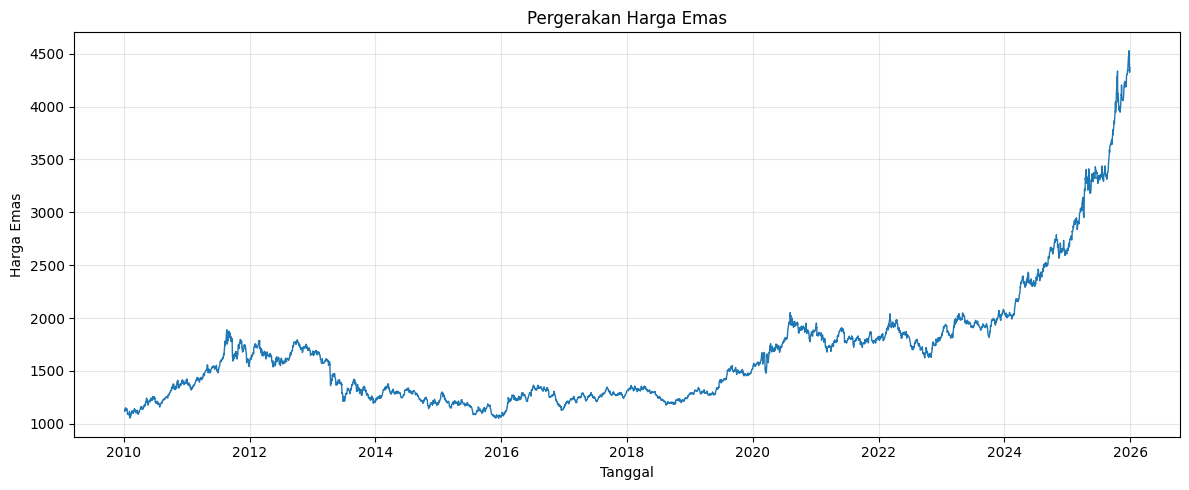

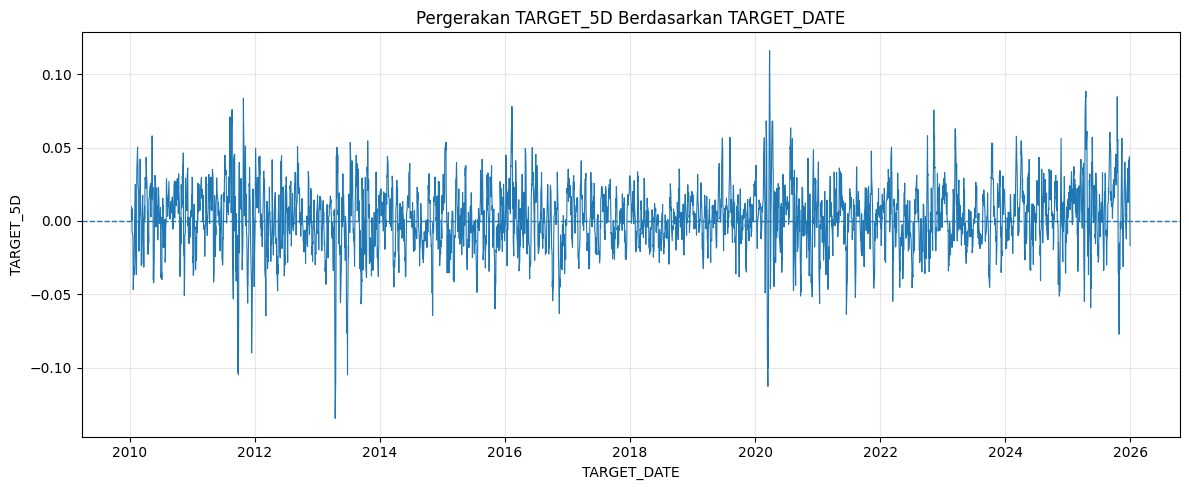

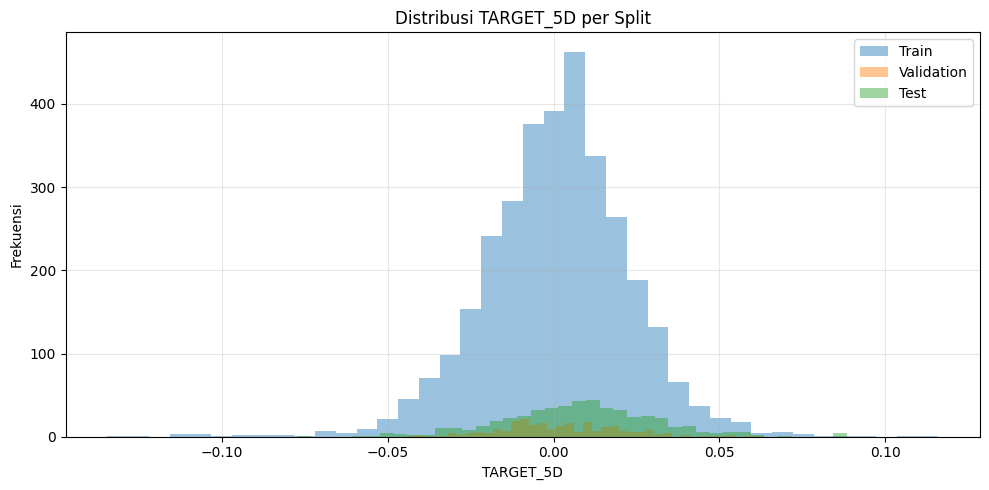

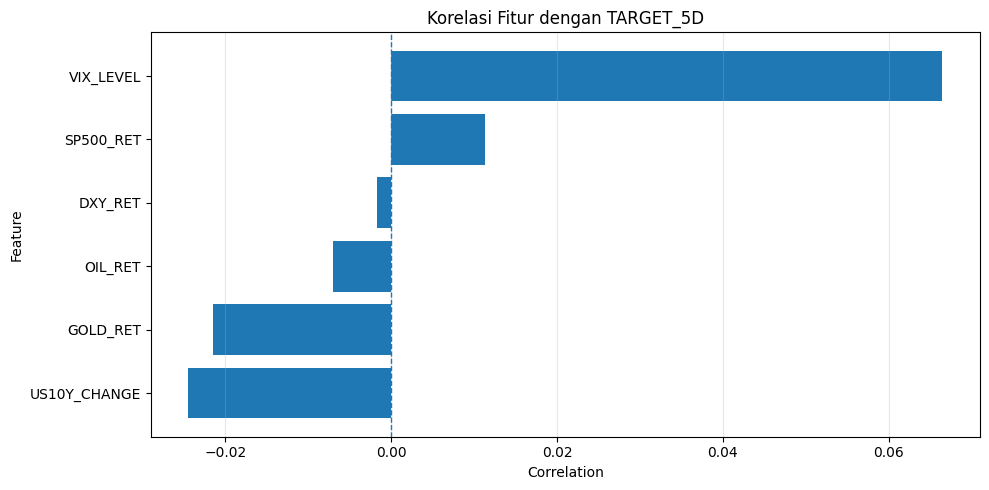

WindowsPath('c:/Users/Afzi/Documents/BINUS/0. SKRIPSI/gold_forecasting_skripsi/results/project_summary/fig_04_feature_correlation_with_target.png')

In [12]:

# Figure 1: Pergerakan harga emas
plt.figure(figsize=(12, 5))
plt.plot(gold_macro["DATE"], gold_macro["GOLD"], linewidth=1)
plt.title("Pergerakan Harga Emas")
plt.xlabel("Tanggal")
plt.ylabel("Harga Emas")
plt.grid(True, alpha=0.3)
save_fig("fig_01_gold_price.png")


# Figure 2: TARGET_5D berdasarkan TARGET_DATE
plt.figure(figsize=(12, 5))
plt.plot(base["TARGET_DATE"], base["TARGET_5D"], linewidth=0.8)
plt.axhline(0, linestyle="--", linewidth=1)
plt.title("Pergerakan TARGET_5D Berdasarkan TARGET_DATE")
plt.xlabel("TARGET_DATE")
plt.ylabel("TARGET_5D")
plt.grid(True, alpha=0.3)
save_fig("fig_02_target_5d_by_target_date.png")


# Figure 3: Distribusi TARGET_5D per split
plt.figure(figsize=(10, 5))
for split_name in ["Train", "Validation", "Test"]:
    subset = base[base["SPLIT"] == split_name]
    plt.hist(subset["TARGET_5D"], bins=40, alpha=0.45, label=split_name)

plt.title("Distribusi TARGET_5D per Split")
plt.xlabel("TARGET_5D")
plt.ylabel("Frekuensi")
plt.legend()
plt.grid(True, alpha=0.3)
save_fig("fig_03_target_distribution_by_split.png")


# Figure 4: Korelasi fitur dengan TARGET_5D
corr_plot = corr_with_target.copy()
corr_plot = corr_plot.sort_values("Correlation_With_TARGET_5D")

plt.figure(figsize=(10, 5))
plt.barh(corr_plot["Feature"], corr_plot["Correlation_With_TARGET_5D"])
plt.axvline(0, linestyle="--", linewidth=1)
plt.title("Korelasi Fitur dengan TARGET_5D")
plt.xlabel("Correlation")
plt.ylabel("Feature")
plt.grid(True, axis="x", alpha=0.3)
save_fig("fig_04_feature_correlation_with_target.png")

### **Visualisasi Actual vs Predicted**

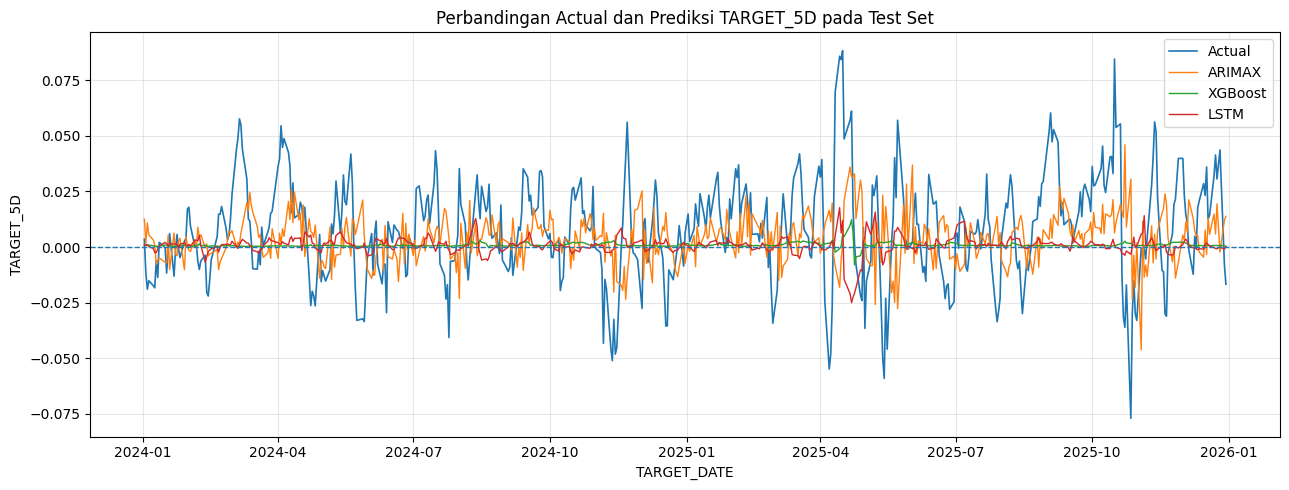

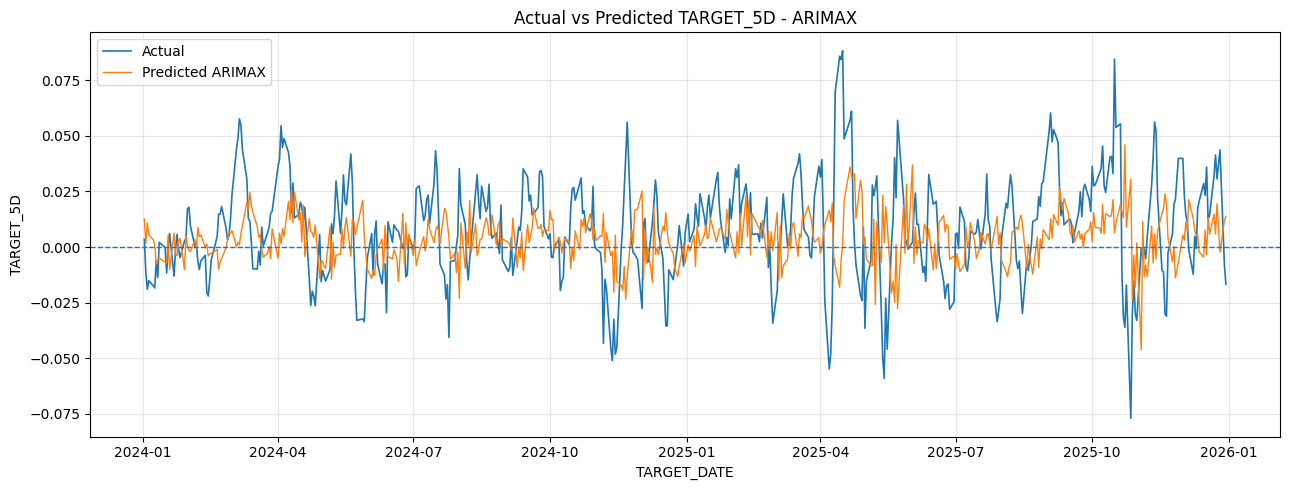

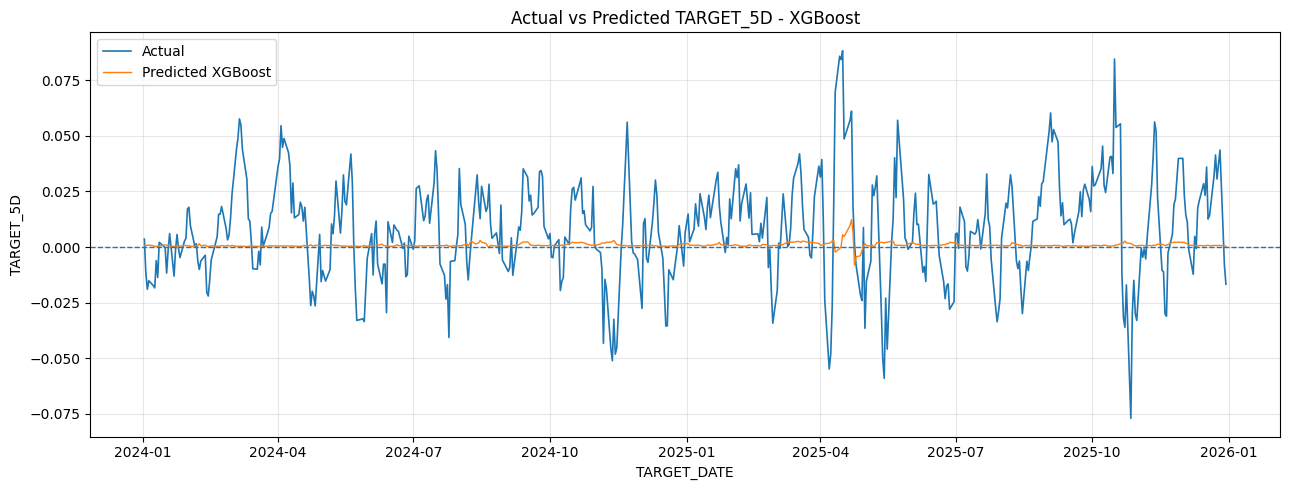

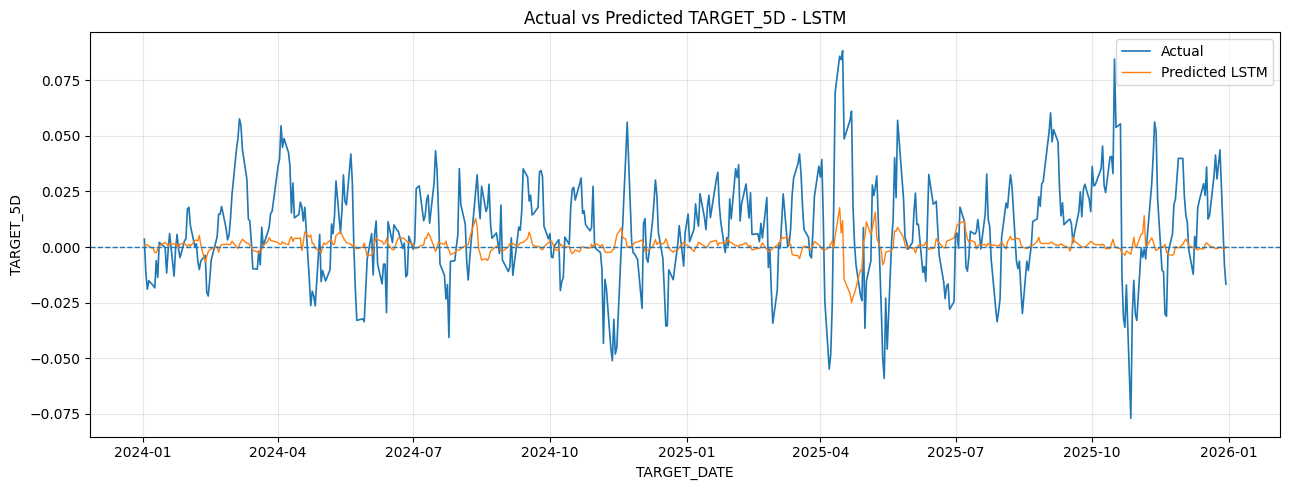

In [13]:

# Figure 5: Actual vs predicted all models
actual_series = test_predictions["ARIMAX"][["TARGET_DATE", "TARGET_5D"]].copy()

plt.figure(figsize=(13, 5))
plt.plot(actual_series["TARGET_DATE"], actual_series["TARGET_5D"], linewidth=1.2, label="Actual")

for model in MODEL_ORDER:
    df = test_predictions[model]
    plt.plot(df["TARGET_DATE"], df["PRED"], linewidth=1, label=model)

plt.axhline(0, linestyle="--", linewidth=1)
plt.title("Perbandingan Actual dan Prediksi TARGET_5D pada Test Set")
plt.xlabel("TARGET_DATE")
plt.ylabel("TARGET_5D")
plt.legend()
plt.grid(True, alpha=0.3)
save_fig("fig_05_actual_vs_pred_all_models.png")


# Individual actual vs predicted figures
for fig_idx, model in enumerate(MODEL_ORDER):
    df = test_predictions[model]

    plt.figure(figsize=(13, 5))
    plt.plot(df["TARGET_DATE"], df["TARGET_5D"], linewidth=1.2, label="Actual")
    plt.plot(df["TARGET_DATE"], df["PRED"], linewidth=1, label=f"Predicted {model}")
    plt.axhline(0, linestyle="--", linewidth=1)
    plt.title(f"Actual vs Predicted TARGET_5D - {model}")
    plt.xlabel("TARGET_DATE")
    plt.ylabel("TARGET_5D")
    plt.legend()
    plt.grid(True, alpha=0.3)

    filename = f"fig_{6 + fig_idx:02d}_actual_vs_pred_{model.lower()}_test.png"
    save_fig(filename)

### **Visualisasi Error dan Arah Prediksi**

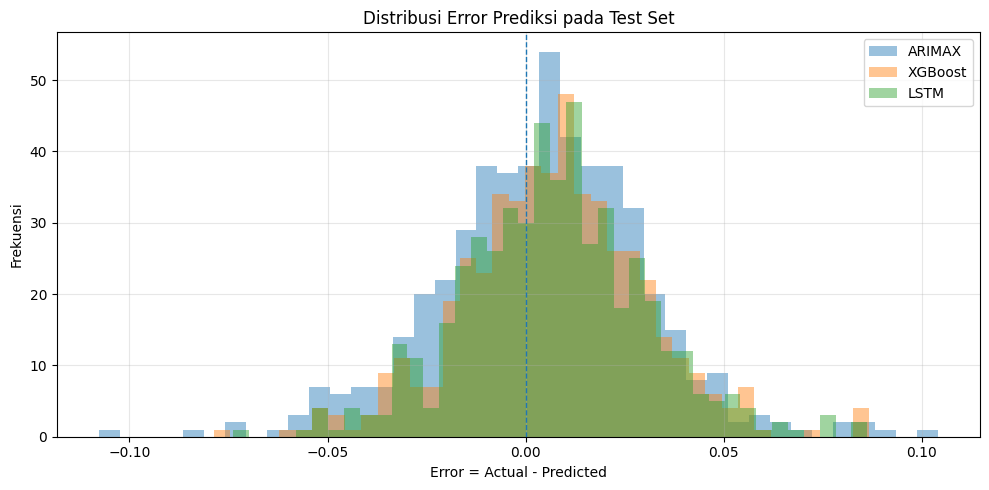

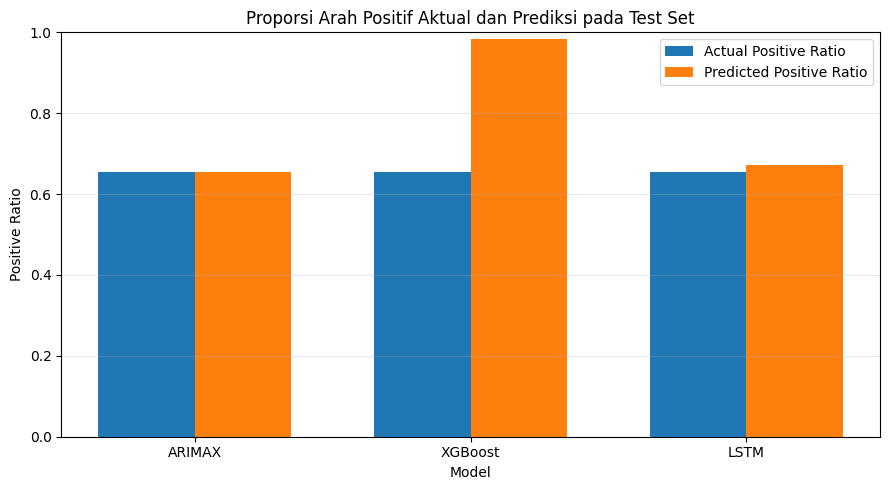

WindowsPath('c:/Users/Afzi/Documents/BINUS/0. SKRIPSI/gold_forecasting_skripsi/results/project_summary/fig_10_positive_direction_ratio_test.png')

In [14]:

# Figure 9: Error distribution by model
plt.figure(figsize=(10, 5))

for model in MODEL_ORDER:
    subset = combined_test_predictions[combined_test_predictions["Model"] == model]
    plt.hist(subset["ERROR"], bins=40, alpha=0.45, label=model)

plt.axvline(0, linestyle="--", linewidth=1)
plt.title("Distribusi Error Prediksi pada Test Set")
plt.xlabel("Error = Actual - Predicted")
plt.ylabel("Frekuensi")
plt.legend()
plt.grid(True, alpha=0.3)
save_fig("fig_09_error_distribution_test.png")


# Figure 10: Actual vs predicted positive direction ratio
direction_df = final_model_comparison[["Model", "Actual_Positive_Ratio", "Pred_Positive_Ratio"]].copy()
direction_df = direction_df.set_index("Model").loc[MODEL_ORDER]

x = np.arange(len(direction_df))
width = 0.35

plt.figure(figsize=(9, 5))
plt.bar(x - width/2, direction_df["Actual_Positive_Ratio"], width, label="Actual Positive Ratio")
plt.bar(x + width/2, direction_df["Pred_Positive_Ratio"], width, label="Predicted Positive Ratio")
plt.xticks(x, direction_df.index)
plt.title("Proporsi Arah Positif Aktual dan Prediksi pada Test Set")
plt.xlabel("Model")
plt.ylabel("Positive Ratio")
plt.ylim(0, 1)
plt.legend()
plt.grid(True, axis="y", alpha=0.3)
save_fig("fig_10_positive_direction_ratio_test.png")

### **Diagnostik Residual (Residual Plot & QQ Plot)**

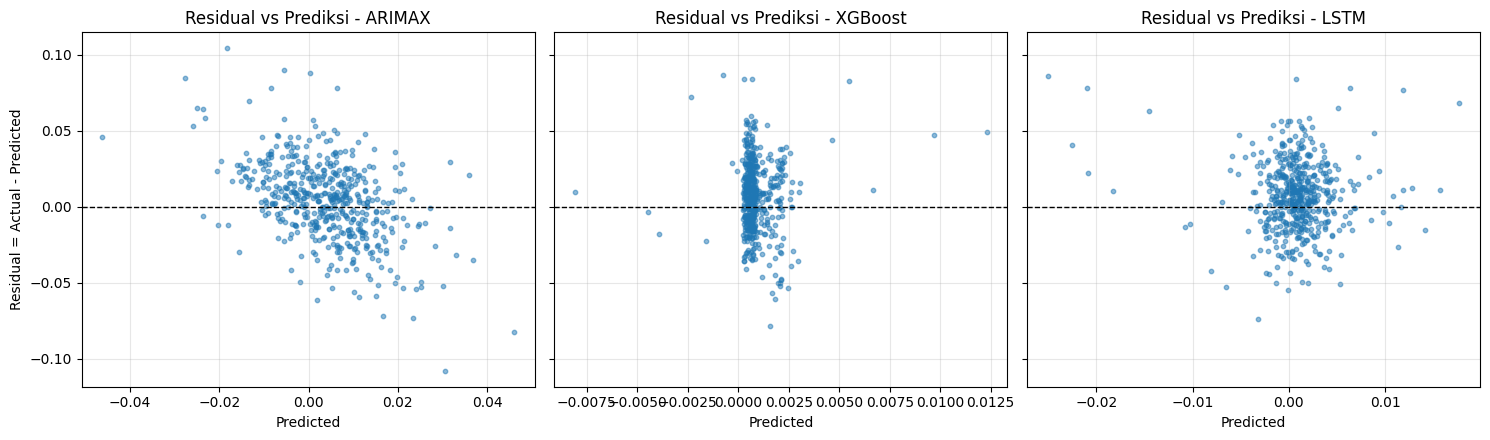

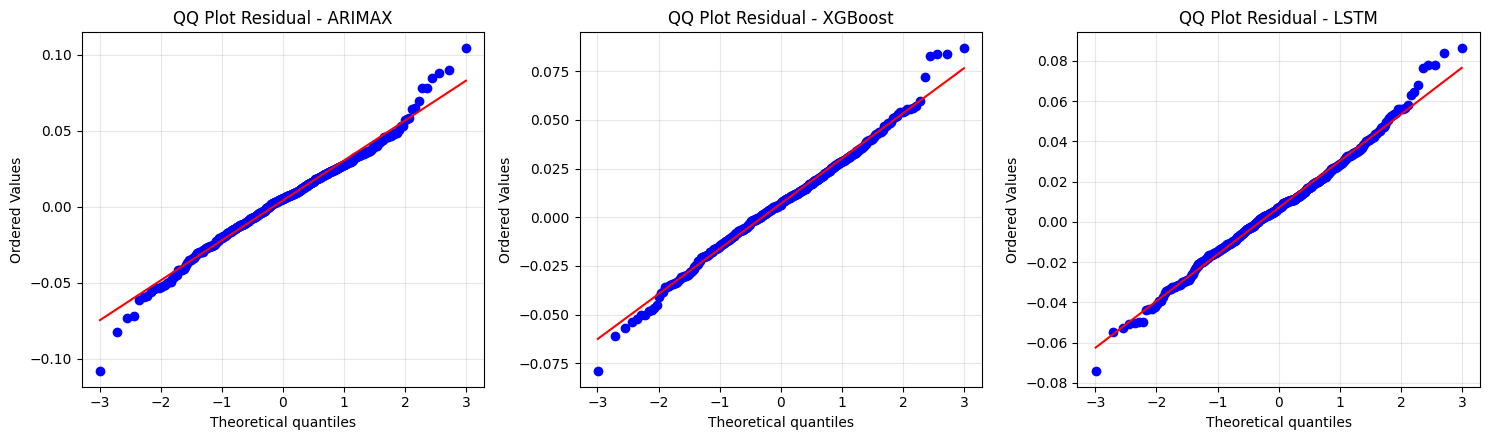

WindowsPath('c:/Users/Afzi/Documents/BINUS/0. SKRIPSI/gold_forecasting_skripsi/results/project_summary/fig_12_qq_plot_residual_test.png')

In [15]:

# Figure 11: Residual terhadap nilai prediksi per model

# Residual = Actual - Predicted. Memeriksa bias sistematis dan
# apakah sebaran error berubah terhadap besar prediksi.

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)
for ax, model in zip(axes, MODEL_ORDER):
    sub = combined_test_predictions[combined_test_predictions["Model"] == model]
    ax.scatter(sub["PRED"], sub["ERROR"], s=10, alpha=0.5)
    ax.axhline(0, linestyle="--", linewidth=1, color="black")
    ax.set_title(f"Residual vs Prediksi - {model}")
    ax.set_xlabel("Predicted")
    ax.grid(True, alpha=0.3)
axes[0].set_ylabel("Residual = Actual - Predicted")
save_fig("fig_11_residual_vs_predicted_test.png")



# Figure 12: QQ plot residual per model terhadap distribusi normal

# Memeriksa normalitas residual. Ekor yang menjauh dari garis
# menandakan distribusi berekor tebal (fat tails).

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, model in zip(axes, MODEL_ORDER):
    sub = combined_test_predictions[combined_test_predictions["Model"] == model]
    stats.probplot(sub["ERROR"].to_numpy(), dist="norm", plot=ax)
    ax.set_title(f"QQ Plot Residual - {model}")
    ax.grid(True, alpha=0.3)
save_fig("fig_12_qq_plot_residual_test.png")


### **Output Check**

In [16]:
generated_tables = sorted([p.name for p in OUTPUT_DIR.glob("*.csv")])
generated_figures = sorted([p.name for p in OUTPUT_DIR.glob("*.png")])

output_check = pd.DataFrame({
    "Output Type": ["Tables", "Figures"],
    "Generated Count": [len(generated_tables), len(generated_figures)],
    "Files": [", ".join(generated_tables), ", ".join(generated_figures)],
})

display(output_check)

print("Project summary selesai.")
print(f"Output folder : {OUTPUT_DIR}")


,Output Type,Generated Count,Files
0,Tables,10,"01_split_summary.csv, 02_feature_descriptive_s..."
1,Figures,12,"fig_01_gold_price.png, fig_02_target_5d_by_tar..."


Project summary selesai.
Output folder : c:\Users\Afzi\Documents\BINUS\0. SKRIPSI\gold_forecasting_skripsi\results\project_summary


### **Preview Ringkas**

In [17]:
print("Final Test Model Comparison")
display(format_float_cols(final_model_comparison))

print("Best Ablation Package by Model")
display(format_float_cols(best_ablation))

print("Prediction Diagnostics")
display(format_float_cols(prediction_diagnostics))
print("Statistical Significance Tests (Diebold-Mariano & Wilcoxon)")
display(format_float_cols(significance_tests, decimals=6))


Final Test Model Comparison


,Model,Rows,Target_Start_Date,Target_End_Date,MAE,RMSE,DA,Actual_Positive_Ratio,Pred_Positive_Ratio,Actual_Mean,Pred_Mean,Actual_Std,Pred_Std,MAE_Rank,RMSE_Rank,DA_Rank
0,LSTM,503.0,2024-01-02,2025-12-30,0.018761,0.024231,0.604374,0.654076,0.671968,0.007891,0.000822,0.023257,0.003840,1.0,2.0,2.0
1,XGBoost,503.0,2024-01-02,2025-12-30,0.018767,0.024214,0.650099,0.654076,0.984095,0.007891,0.000892,0.023257,0.001092,2.0,1.0,1.0
2,ARIMAX,503.0,2024-01-02,2025-12-30,0.020588,0.026676,0.510934,0.654076,0.654076,0.007891,0.003740,0.023257,0.010642,3.0,3.0,3.0


Best Ablation Package by Model


,Model,package,features,MAE,RMSE,DA,num_features,num_base_features,num_sequence_features,base_features,architecture,learning_rate,loss,best_epoch,best_val_loss_scaled,MAE_Rank,RMSE_Rank,DA_Rank
0,ARIMAX,FULL,"DXY_RET, SP500_RET, OIL_RET, US10Y_CHANGE, VIX...",0.014190,0.018560,0.592,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,2.0
1,LSTM,NO_G3,NaN,0.014633,0.018731,0.544,NaN,5.0,35.0,"GOLD_RET, DXY_RET, SP500_RET, US10Y_CHANGE, VI...",MEDIUM,0.001,Huber,14.0,0.312849,1.0,3.0,1.0
2,XGBoost,NO_G3,"GOLD_RET, GOLD_RET_LAG1, GOLD_RET_LAG2, GOLD_R...",0.014775,0.018682,0.520,40.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,2.0,1.0


Prediction Diagnostics


,Model,Rows,Actual_Mean,Pred_Mean,Actual_Std,Pred_Std,Pred_Min,Pred_Max,Error_Mean,Abs_Error_Mean,Actual_Positive_Ratio,Pred_Positive_Ratio,Unique_Pred_Rounded_10
0,ARIMAX,503.0,0.007891,0.003740,0.023257,0.010642,-0.046222,0.045989,0.004151,0.020588,0.654076,0.654076,503.0
1,LSTM,503.0,0.007891,0.000822,0.023257,0.003840,-0.025062,0.017714,0.007070,0.018761,0.654076,0.671968,503.0
2,XGBoost,503.0,0.007891,0.000892,0.023257,0.001092,-0.008082,0.012302,0.006999,0.018767,0.654076,0.984095,485.0


Statistical Significance Tests (Diebold-Mariano & Wilcoxon)


,Comparison,Model_A,Model_B,Loss_Type,Mean_Loss_Diff_A_minus_B,DM_Stat,DM_p_value,Wilcoxon_p_value,N,NW_Lags,Significant_5pct,Conclusion
0,LSTM vs XGBoost,LSTM,XGBoost,MAE (abs),-0.000005,-0.019560,0.984402,0.270075,503.0,4.0,False,Tidak berbeda signifikan
1,LSTM vs XGBoost,LSTM,XGBoost,RMSE (squared),0.000001,0.033079,0.973625,0.158143,503.0,4.0,False,Tidak berbeda signifikan
2,LSTM vs ARIMAX,LSTM,ARIMAX,MAE (abs),-0.001826,-2.615911,0.009167,0.000258,503.0,4.0,True,LSTM lebih baik (signifikan)
3,LSTM vs ARIMAX,LSTM,ARIMAX,RMSE (squared),-0.000124,-2.347399,0.019292,0.000428,503.0,4.0,True,LSTM lebih baik (signifikan)
4,XGBoost vs ARIMAX,XGBoost,ARIMAX,MAE (abs),-0.001821,-2.942473,0.003407,0.000242,503.0,4.0,True,XGBoost lebih baik (signifikan)
5,XGBoost vs ARIMAX,XGBoost,ARIMAX,RMSE (squared),-0.000125,-3.127697,0.001864,0.000284,503.0,4.0,True,XGBoost lebih baik (signifikan)
6,LSTM vs ZERO,LSTM,ZERO,MAE (abs),-0.000312,-1.313872,0.189489,0.000609,503.0,4.0,False,Tidak berbeda signifikan
7,LSTM vs ZERO,LSTM,ZERO,RMSE (squared),-0.000015,-0.770622,0.441294,0.000145,503.0,4.0,False,Tidak berbeda signifikan
8,XGBoost vs ZERO,XGBoost,ZERO,MAE (abs),-0.000306,-3.243873,0.001258,0.000000,503.0,4.0,True,XGBoost lebih baik (signifikan)
9,XGBoost vs ZERO,XGBoost,ZERO,RMSE (squared),-0.000016,-2.039793,0.041894,0.000000,503.0,4.0,True,XGBoost lebih baik (signifikan)
